# OpenPRBB

In this example, we are going to create a bacterial model and grow a colony using it.



## Load the packages

In [1]:
using Base.Threads
println("Usando ", nthreads(), " threads 😎")

Usando 4 threads 😎


In [2]:
# import Pkg
# Pkg.activate("../")
# Pkg.instantiate()


In [3]:
# import Pkg; Pkg.add(["Revise", "GLMakie"])

In [4]:
# using Revise
# using CellBasedModels
# using CUDA
# using Distributions
# using GLMakie
# # using GeometryBasics
# import GLMakie: Point3f, Cylinder, Sphere, NoShading #Can be changes to Cairo or CLMakie

In [5]:
import Pkg

# Activa el entorno del proyecto
# Pkg.activate("C:/Users/julia/OneDrive/Escritorio/phd/Bacteria_ABM/ABM_CBM/")

Pkg.activate("/home/julia/Escritorio/Projects/Pushing/ABM_CBM")


# Resuelve y asegura dependencias
Pkg.resolve()
Pkg.instantiate()


# Carga los paquetes de forma ordenada
using Revise
using CellBasedModels
ENV["JULIA_CUDA_USE_BINARYBUILDER"] = false  # (opcional, fuerza compilación local)
using CUDA
CUDA.set_runtime_version!(v"12.2")
using Distributions
using CairoMakie
using JSON

# Importa funciones específicas después
import CairoMakie: Point3f, Cylinder, Sphere, NoShading

CairoMakie.activate!()


  Activating project at `~/Escritorio/Projects/Pushing/ABM_CBM`
  No Changes to `~/Escritorio/Projects/Pushing/ABM_CBM/Project.toml`
  No Changes to `~/Escritorio/Projects/Pushing/ABM_CBM/Manifest.toml`
┌ Info: Configure the active project to use CUDA 12.2; please re-start Julia for this to take effect.
└ @ CUDA /home/julia/.julia/packages/CUDA/jdJ7Z/lib/cudadrv/version.jl:82


## Forces model

We already use the defined forces model that is implemented in CBqodels. This is an exact copy of the rod model that you can find already predefined in `Models/rods.jl`. You can check the `Models` section of the documentation for more details.


In [6]:
rod2D = ABM(2,
    agent = Dict(
            :theta=>Float64,
            :d=>Float64,
            :l=>Float64,
            :fx=>Float64,
            :fy=>Float64,
            :W=>Float64,
        ),    #Local Interaction Parameters

    model = Dict(
            :E=>Float64,
            :eta=>Float64,

        ),        #Global parameters

    agentODE = quote

        fx = 0
        fy = 0
        W = 0
        @loopOverNeighbors i2 begin

            #Use the model provided in the documentation
            Fijx, Fijy, Wij = CBMModels.repulsiveForces_rods(x,y,d,l,theta,
                                    x[i2],y[i2],d[i2],l[i2],theta[i2],eta, E)

            #Append the repulsive forces
            fx += Fijx
            fy += Fijy
            W += Wij
            
        end

        #Equations
        dt(x) =  fx 
        dt(y) =  fy 
        dt(theta) =  W
    end,

    neighborsAlg=CBMNeighbors.CellLinked(cellEdge=4),
    platform=CPU(),
    agentAlg = CBMIntegrators.Heun()
);


### Initialize a coqunity with two bacteries and check forces

In [20]:
com = Community(rod2D,
            N=30,
            dt=0.0001,
            simBox = [-10 10;-10 10.],
            );


#Natural units scales
m = 1.E3 #g
t = 1/(60*60) # h
d = 1.E6 #um


com.E=1* 1.E6 *m/(t^2*d) #Pa
com.eta = 200 *m/(t^2*d) #Pa h
 

com.d = 1.        
com.l = 3.99      



com.x = 0
com.y = 0
com.theta = 0;


In [21]:
com.N

30

In [22]:
for i in 1:com.N
    com.theta[i] = rand() * 2π
    com.x[i] = rand()*10-5
    com.y[i] = rand()*10-5
    com.l[i] = 3.0
    com.d[i] = 1.0

end

In [23]:
evolve!(com,steps=50,saveEach=10,preallocateAgents=com.N)

In [24]:
function plotAgents2D!(ax, x, y, d, l, angle, p; colormap=:inferno, kargs...)
    for (xi, yi, li, di, ai, pi) in zip(x, y, l, d, angle, p)



            colorval = pi
            # colormap = :inferno
            meshscatter!(ax,
                [xi + li/2 * cos(ai)],
                [yi + li/2 * sin(ai)];
                marker = Sphere(Point3f(0, 0, 0), Float32(1)),
                markersize = [Point3f(di/2, di/2, di/2)],
                color = [colorval],
                colormap = colormap,
                kargs...
            )
            meshscatter!(ax,
                [xi - li/2 * cos(ai)],
                [yi - li/2 * sin(ai)];
                marker = Sphere(Point3f(0, 0, 0), Float32(1)),
                markersize = [Point3f(di/2, di/2, di/2)],
                color = [colorval],
                colormap = colormap,
                kargs...
            )
            meshscatter!(ax,
                [xi],
                [yi];
                marker = Cylinder(Point3f(-.5, 0, 0), Point3f(.5, 0, 0), Float32(1)),
                markersize = [Point3f(li, di/2, di/2)],
                rotation = [ai],
                color = [colorval],
                colormap = colormap,
                kargs...
            )

    end
    return
end


plotAgents2D! (generic function with 1 method)

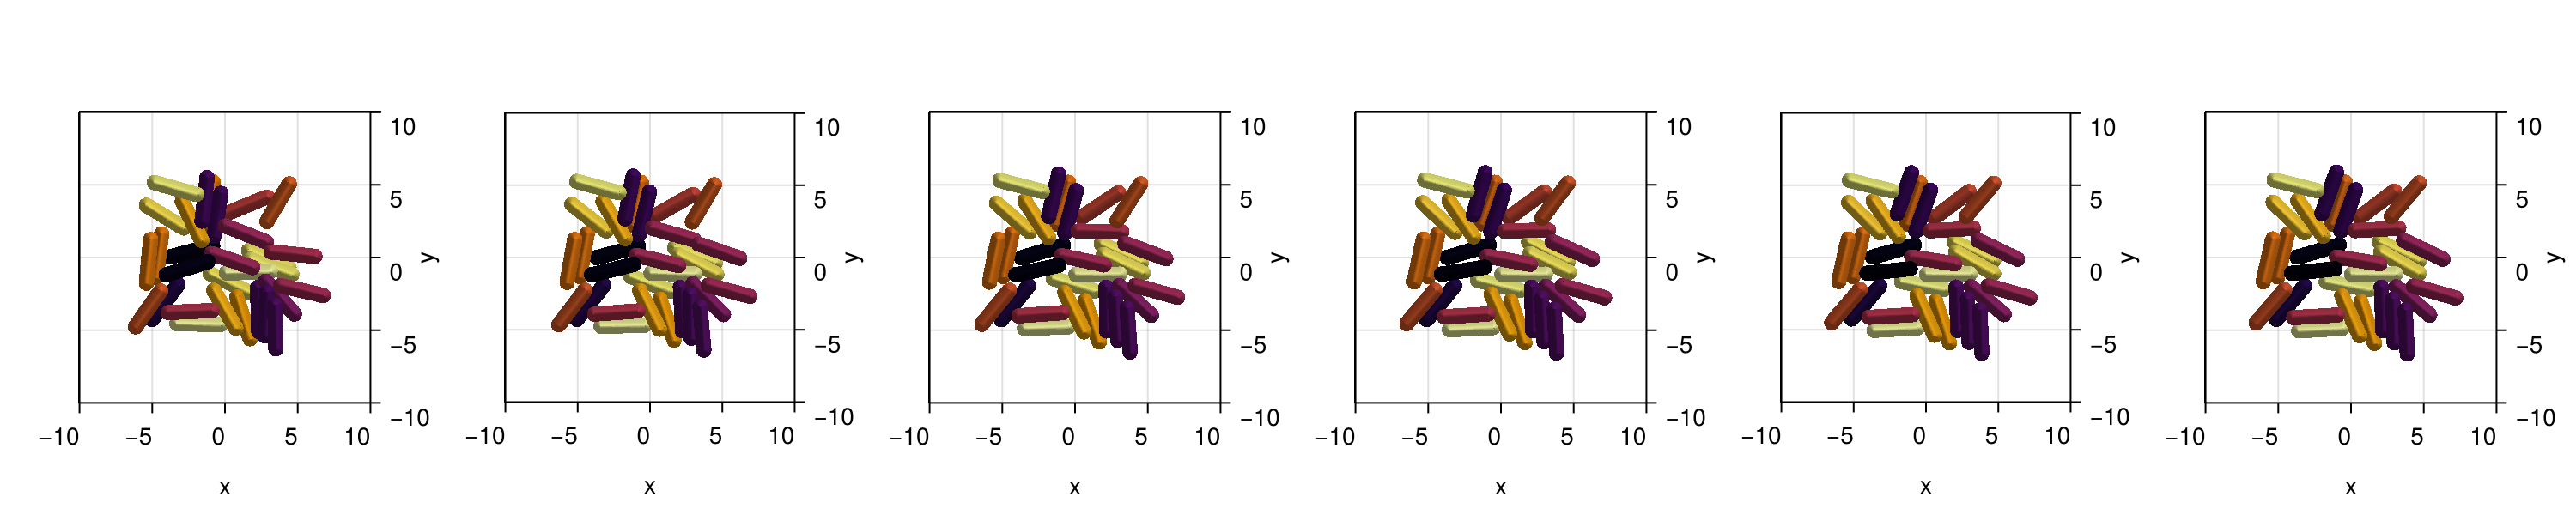

CairoMakie.Screen{IMAGE}


In [25]:
fig = Figure(size=(1500,300))

for (i,j) in enumerate([1:round(Int,length(com)/4):length(com);length(com)])
    ax = Axis3(fig[1,i],
                azimuth=3*π/2,
                elevation=π/2,
                zlabelvisible=false,
                zticklabelsvisible=false,
                zgridvisible=false,
                zspinesvisible=false
            )

    plotAgents2D!(
    ax,
    com[j][:x],
    com[j][:y],
    com[j][:d],
    com[j][:l],
    com[j][:theta],
    com[j][:theta],
    colorrange = (0, 2*pi)
)

    xlims!(-10,10)
    ylims!(-10,10)
end

display(fig)

In [26]:

function log_community_state(parameters::OrderedDict, t::Int, path::String = "Tods_c.txt")
    # Convert keys to strings so JSON can serialize them
    string_keys = Dict(string(k) => v for (k, v) in parameters)
    # Build entry
    entry = Dict("t" => t, "parameters" => string_keys)
    # Save as a JSON line
    open(path, "a") do io
        println(io, JSON.json(entry))
    end
end


function load_parameters_log(path::String = "Tods_c.txt")
    log = Dict{Int, OrderedDict{Symbol, Any}}()
    for line in eachline(path)
        entry = JSON.parse(line)
        t = entry["t"]
        raw_params = entry["parameters"]
        params = OrderedDict(Symbol(k) => v for (k, v) in raw_params)
        log[t] = params
    end
    times = sort(collect(keys(log)))
    com_array = [log[t] for t in times]
    return com_array, times
end



load_parameters_log (generic function with 2 methods)

## Growth model

We construct over the forces model to add bacterial growth and cell division rules.

In [33]:
rods_PGA = ABM(2,

    agent = Dict(
                :theta=>Float64,
                :d=>Float64,
                :l=>Float64,
                :fx=>Float64,
                :fy=>Float64,
                :W=>Float64,
                :lTarget => Float64,
                :growth=>Float64,
                :Kc => Float64, #Half saturation constant for the medium
                :generation => Int,
                :Vm => Float64,
            ),

    model = Dict(
                :E=>Float64,
                :eta=>Float64,
                :σlTarget=>Float64,
                :lMax=>Float64,
                :D_c => Float64,
                :beta_c => Float64, #Uptake rate of the cells in the medium
                :alpha_V =>Float64, 
                :delta_V =>Float64, 
                :beta_V =>Float64, 
                :KVc =>Float64,
                :cm => Float64,

            ),
    
    medium = Dict(
        :c => Float64,        #Add a medium parameter
    ),

 
    agentODE = quote  
        
        dt(l) = l*growth*c/(Kc+c) 

        fx = 0
        fy = 0
        W = 0
        @loopOverNeighbors i2 begin
            #Use the model provided in the documentation
            Fijx, Fijy, Wij = CBMModels.repulsiveForces_rods(x,y,d,l,theta,
                                    x[i2],y[i2],d[i2],l[i2],theta[i2],eta, E)

            #Append the repulsive forces
            fx += Fijx
            fy += Fijy
            W += Wij            
        end

        #Equations
        dt(x) =  fx 
        dt(y) =  fy 
        dt(theta) =  W
        dt(Vm) =  alpha_V - Vm*delta_V - beta_V*1/(1 + (c/KVc))
    end,

    agentRule = quote #Bound cells

        #Add division
        if l > lTarget
            ww = CBMDistributions.uniform(-1,1) #To add some random torque at division time

            # ww = 0 #To add some random torque at division time
            #Add a new cell
            @addAgent(
                    x=(l+d)/4*cos(theta)+x,
                    y=(l+d)/4*sin(theta)+y,
                    l=(l-d)/2,
                    W=ww,
                    lTarget = CBMDistributions.uniform(lMax-σlTarget,lMax+σlTarget),
                    )
            #Add a second cell
            @addAgent(
                    x=-(l+d)/4*cos(theta)+x,
                    y=-(l+d)/4*sin(theta)+y,
                    l=(l-d)/2,
                    lTarget = CBMDistributions.uniform(lMax-σlTarget,lMax+σlTarget), #New target length at which the bactery should divide
                    W=ww)
            #Remove the old cell
            @removeAgent()
        end
        
        c += (-l*beta_c*c/(Kc+c))*dt
    end,

    #Medium dynamics with dirichlet conditions and a wall that is as oscillating source of material
    mediumODE=quote 

        if @mediumInside()
            dt(c) =D_c*(@∂2(1,c)+@∂2(2,c))
        elseif @mediumBorder(1,-1) 
            c = cm
        elseif @mediumBorder(1,1)
            c = cm
        elseif @mediumBorder(2,-1)
            c = cm
        elseif @mediumBorder(2,1)
            c = cm
        end
    end,

    neighborsAlg=CBMNeighbors.CellLinked(cellEdge=4),
    platform=CPU(),
    agentAlg=CBMIntegrators.Heun(),
    mediumAlg=DifferentialEquations.Euler(),
);

In [34]:
com = Community(rods_PGA,
            N=1,
            dt=0.0001,
            simBox = [-100 100;-100 100.],
            NMedium=[100,100],
            );


#Natural units scales
m = 1.E3 #g
t = 1/(60*60) # h
d = 1.E6 #um


com.E=5* 1.E5 *m/(t^2*d) #Pa
com.eta = 200 *m/(t^2*d) #Pa h

com.growth = 5.
com.lMax = 4.     
com.σlTarget = 1.5 

com.d = 1.        
com.l = 3.99      
com.lTarget = 4.  
com.x=0
com.y=0
com.theta=0




com.D_c = 1000
com.cm = 1 #Medium concentration
com.c = com.cm 
com.Kc = 1 #Half saturation constant for the medium
com.beta_c = 50 #Growth rate of the cells in the medium


com.Vm = -149
com.alpha_V = -150
com.delta_V = 1
com.beta_V = 100
com.KVc = 5E-4





0.0005

In [35]:
open("Tods_c.txt", "w") do f
    # clear file at start
end

In [36]:
prev_steps=Int(round(0/com.dt))
steps=Int(round(30/com.dt))
saveEach = Int(round(1/com.dt))/10
N=com.N*4

loadToPlatform!(com,preallocateAgents=N)

step=prev_steps
log_community_state(com.parameters, step)


while (step<steps+1) & (com.N < 2000)
    
    step!(com)

    if step % saveEach == 0
        bringFromPlatform!(com)
        if N - com.N[1] <= 0
                println("Step ",step, " N: ", com.N[1], " preallocateAgents: ", N)
                @warn "More agents than preallocateAgents, stopping simulation."
                break
        elseif   N - com.N[1]  < 4*com.N[1]
                N = 15*com.N[1]
        end 
        println("Step ",step, " N: ", com.N[1])
        log_community_state(com.parameters, step)
        loadToPlatform!(com,preallocateAgents=N)
    end
    step += 1
end
bringFromPlatform!(com)

Step 0 N: 1
Step 1000 N: 2
Step 2000 N: 2
Step 3000 N: 2
Step 4000 N: 3
Step 5000 N: 3
Step 6000 N: 4
Step 7000 N: 4
Step 8000 N: 5
Step 9000 N: 6
Step 10000 N: 7
Step 11000 N: 7
Step 12000 N: 8
Step 13000 N: 10
Step 14000 N: 10
Step 15000 N: 12
Step 16000 N: 14
Step 17000 N: 16
Step 18000 N: 16
Step 19000 N: 17
Step 20000 N: 19
Step 21000 N: 19
Step 22000 N: 20
Step 23000 N: 21
Step 24000 N: 22
Step 25000 N: 25
Step 26000 N: 29
Step 27000 N: 29
Step 28000 N: 30
Step 29000 N: 31
Step 30000 N: 34
Step 31000 N: 36
Step 32000 N: 37
Step 33000 N: 37
Step 34000 N: 39
Step 35000 N: 39
Step 36000 N: 41
Step 37000 N: 43
Step 38000 N: 47
Step 39000 N: 49
Step 40000 N: 50
Step 41000 N: 51
Step 42000 N: 52
Step 43000 N: 52
Step 44000 N: 54
Step 45000 N: 54
Step 46000 N: 57
Step 47000 N: 58
Step 48000 N: 60
Step 49000 N: 64
Step 50000 N: 65
Step 51000 N: 66
Step 52000 N: 69
Step 53000 N: 70
Step 54000 N: 71
Step 55000 N: 73
Step 56000 N: 77
Step 57000 N: 82
Step 58000 N: 83
Step 59000 N: 84
Step 6

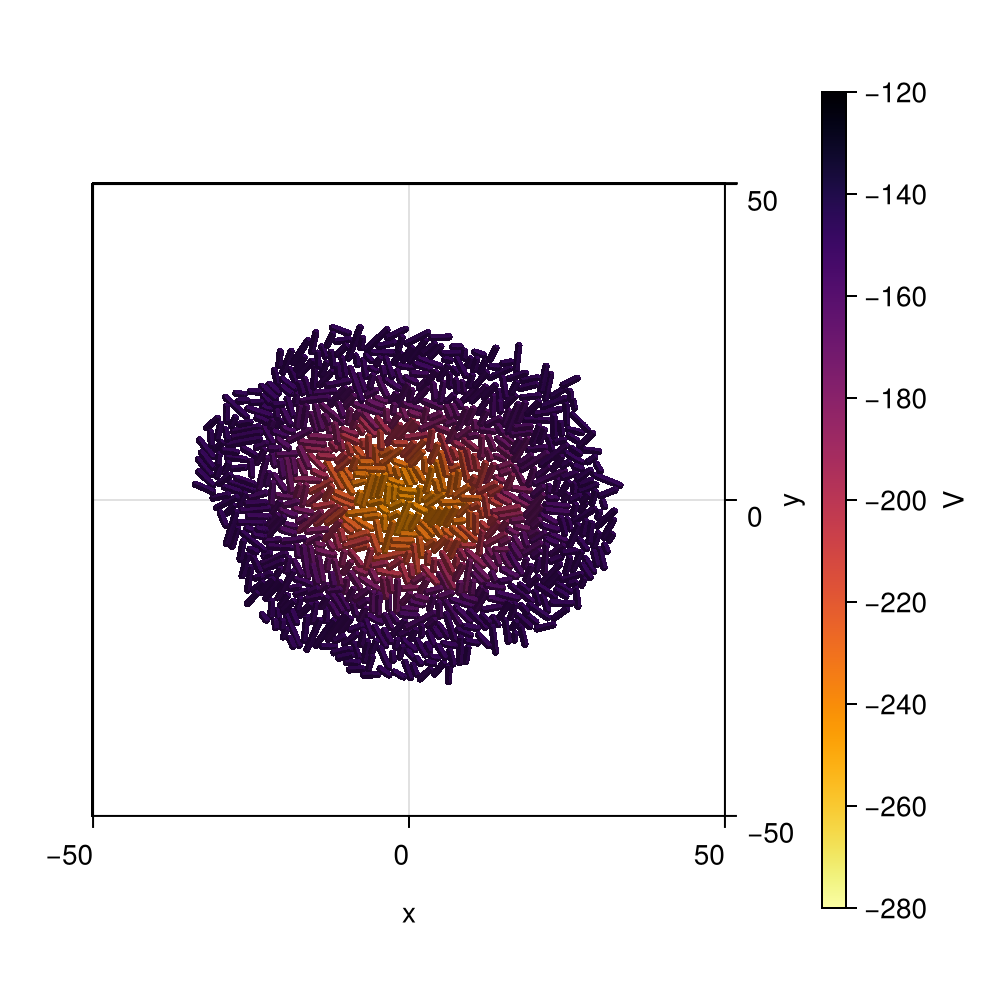

CairoMakie.Screen{IMAGE}


In [37]:
com_load,times=load_parameters_log("Tods_c.txt")
simBox_cpu = Array(com.simBox)  # copia a CPU

cmap_transp_orange = cgrad(
    [RGBAf(1.0, 0.55, 0, 0.0),   # verde con alfa 0 (transparente)
     RGBAf(1.0, 0.55, 0, 1.0)],  # verde con alfa 1 (opaco)
    506
)

colormap_c=cmap_transp_orange
# colormap_c=:Oranges
# colorrange_c = (0.0,  maximum(maximum(p -> maximum(p[:c]), com_load)))
colorrange_c = (0.0,  maximum(maximum(p -> maximum(p[:c]), com_load)))

fig = Figure(size=(500,500))

js =  length(com_load)

for (i,j) in enumerate(js)
    ax = Axis3(fig[1,i],
                azimuth=3*π/2,
                elevation=π/2,
                zlabelvisible=false,
                zticklabelsvisible=false,
                zgridvisible=false,
                zspinesvisible=false
            )

    plotAgents2D!(
    ax,
    com_load[j][:x],
    com_load[j][:y],
    com_load[j][:d],
    com_load[j][:l],
    com_load[j][:theta],
    com_load[j][:Vm],
    colormap = Reverse(:inferno),
    colorrange =  (-280, -120),
    )

    xlims!(-50,50)
    ylims!(-50,50)
end

Colorbar(fig[1, length(js) + 1],
    colormap = Reverse(:inferno),
    colorrange = (-280, -120),
    label = "V"
)
display(fig)

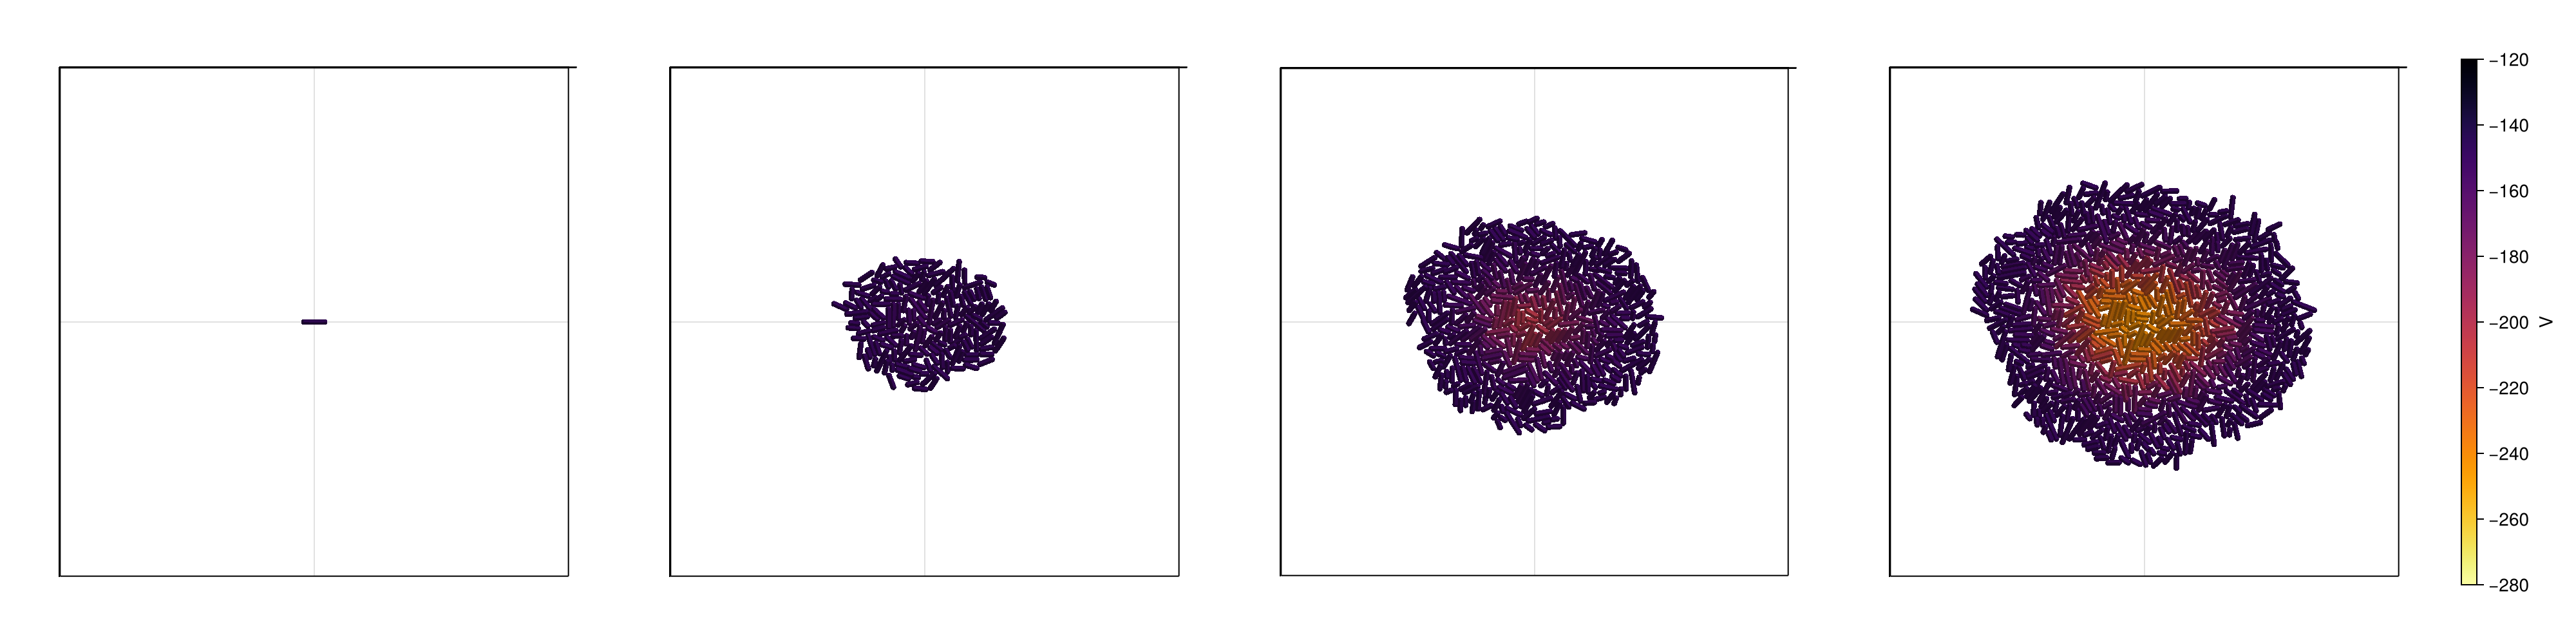

CairoMakie.Screen{IMAGE}


In [39]:
com_load,times=load_parameters_log("Tods_c.txt")
fig = Figure(size=(2000,500))

# js = [1:round(Int, length(com_load)/4):length(com_load); length(com_load)]
# js =  length(com_load)
js = round.(Int, range(1, length(com_load), length=4))
for (i,j) in enumerate(js)
    ax = Axis3(fig[1,i],
                azimuth=3*π/2,
                elevation=π/2,
                zlabelvisible=false,
                zticklabelsvisible=false,
                zgridvisible=false,
                zspinesvisible=false,
                xticksvisible=false,
                yticksvisible=false,
                xticklabelsvisible=false,
                yticklabelsvisible=false,
                xlabelvisible=false,
                ylabelvisible=false

            )

    plotAgents2D!(
    ax,
    com_load[j][:x],
    com_load[j][:y],
    com_load[j][:d],
    com_load[j][:l],
    com_load[j][:theta],
    com_load[j][:Vm],
    colormap = Reverse(:inferno),
    colorrange =  (-280, -120),
    )

    xlims!(-50,50)
    ylims!(-50,50)
end
Colorbar(fig[1, length(js) + 1],
    colormap = Reverse(:inferno),
    colorrange =  (-280, -120),
    label = "V"
)
display(fig)

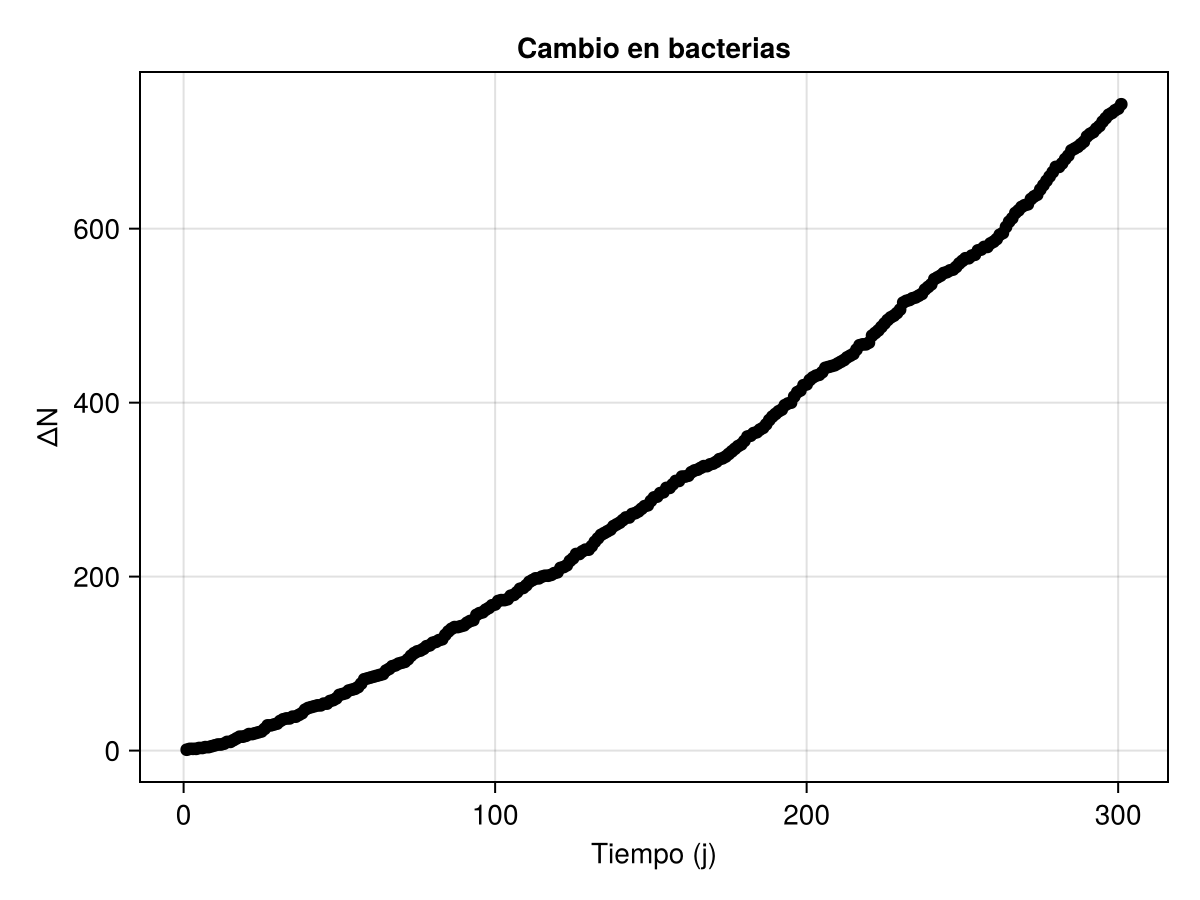

In [ ]:
# Extraemos N
N = [length(com_load[j][:x]) for j in 1:length(com_load)]
V = [minimum(minimum(com_load[j][:Vm])) for j in 1:length(com_load)]

# Diferencia entre tiempos consecutivos
dN = diff(N)

# Eje temporal (para diff hay un punto menos)
t = 1:length(N)

# Figura y ejes
fig = Figure()
ax = Axis(fig[1, 1], xlabel = "Tiempo (j)", ylabel = "ΔN", title = "Cambio en bacterias")

# Scatter plot
scatter!(ax, t, N, color = :black)


fig

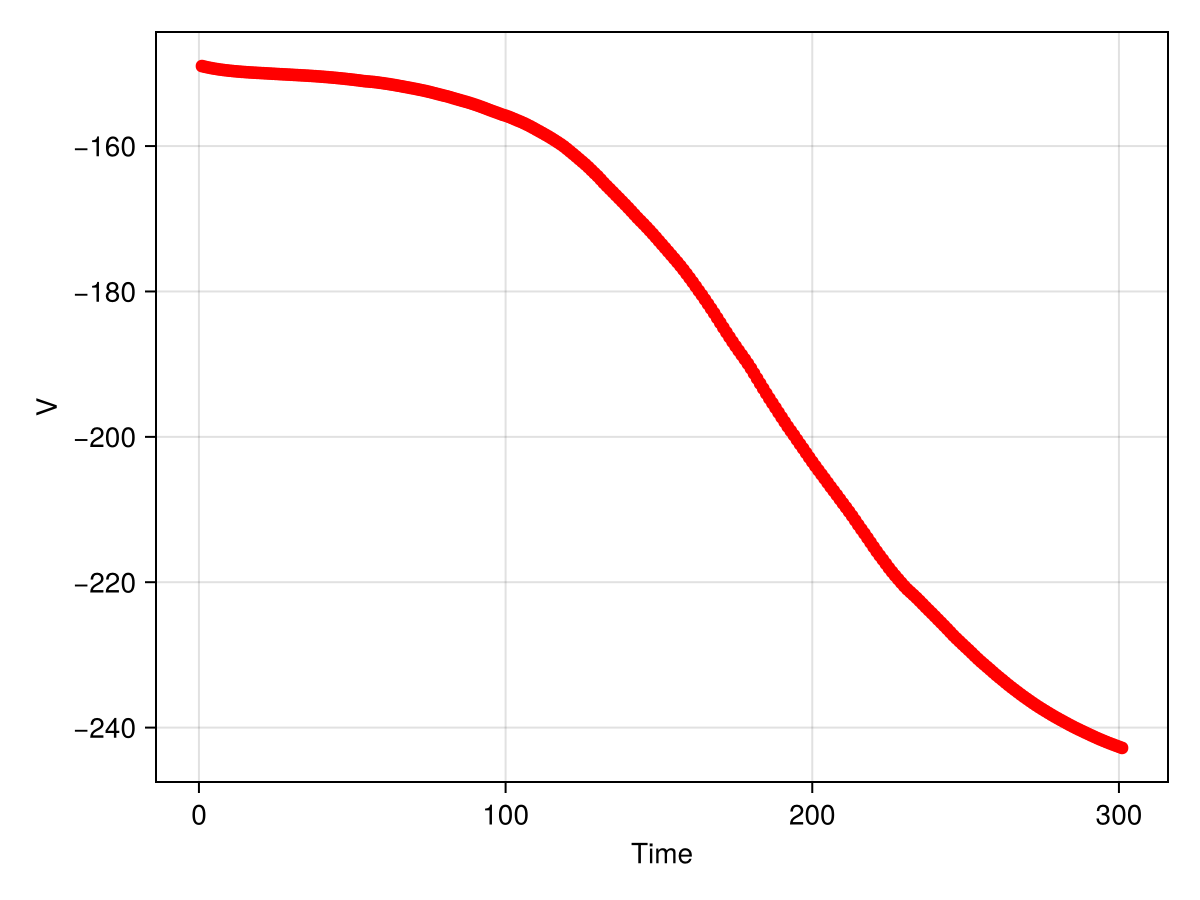

In [43]:
# Figura y ejes
fig = Figure()
ax = Axis(fig[1, 1], xlabel = "Time", ylabel = "V")

# Scatter plot
scatter!(ax, t, V, color = :red)
fig

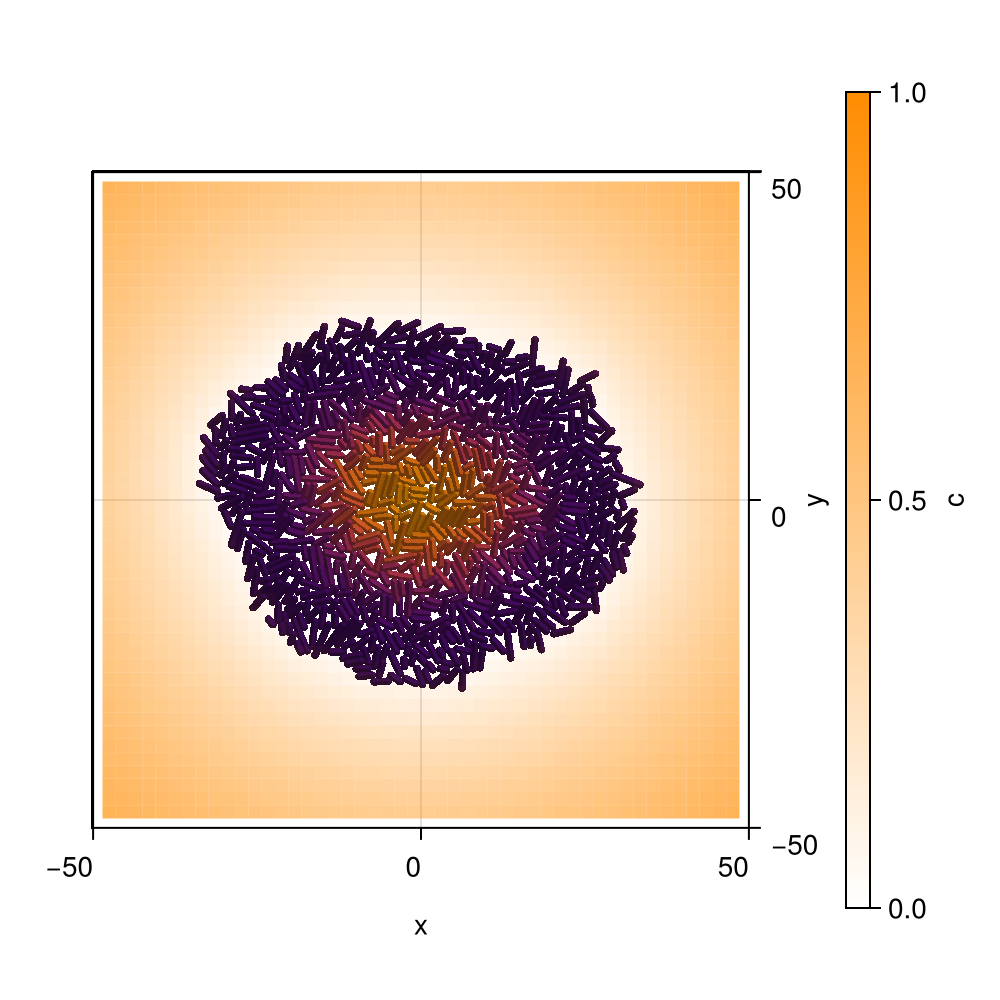

CairoMakie.Screen{IMAGE}


In [44]:
com_load,times=load_parameters_log("Tods_c.txt")
simBox_cpu = Array(com.simBox)  # copia a CPU

cmap_transp_orange = cgrad(
    [RGBAf(1.0, 0.55, 0, 0.0),   # verde con alfa 0 (transparente)
     RGBAf(1.0, 0.55, 0, 1.0)],  # verde con alfa 1 (opaco)
    506
)

colormap_c=cmap_transp_orange
# colormap_c=:Oranges
# colorrange_c = (0.0,  maximum(maximum(p -> maximum(p[:c]), com_load)))
colorrange_c = (0.0,  maximum(maximum(p -> maximum(p[:c]), com_load)))

fig = Figure(size=(500,500))

js =  length(com_load)

for (i,j) in enumerate(js)
    ax = Axis3(fig[1,i],
                azimuth=3*π/2,
                elevation=π/2,
                zlabelvisible=false,
                zticklabelsvisible=false,
                zgridvisible=false,
                zspinesvisible=false
            )

    plotAgents2D!(
    ax,
    com_load[j][:x],
    com_load[j][:y],
    com_load[j][:d],
    com_load[j][:l],
    com_load[j][:theta],
    com_load[j][:Vm],
    colormap = Reverse(:inferno),
    colorrange =  (-280, -120),
    )

    m2 = heatmap!(ax,
            range(simBox_cpu[1,1],simBox_cpu[1,2],length=size(com.c)[1]),
            range(simBox_cpu[2,1],simBox_cpu[2,2],length=size(com.c)[1]),
            Float64.(hcat(com_load[j][:c]...)),
            colormap = colormap_c,
            colorrange = colorrange_c
        )

    xlims!(-50,50)
    ylims!(-50,50)
end
Colorbar(fig[1, length(js) + 1],
    colormap = colormap_c,
    colorrange = colorrange_c,
    label = "c"
)
display(fig)

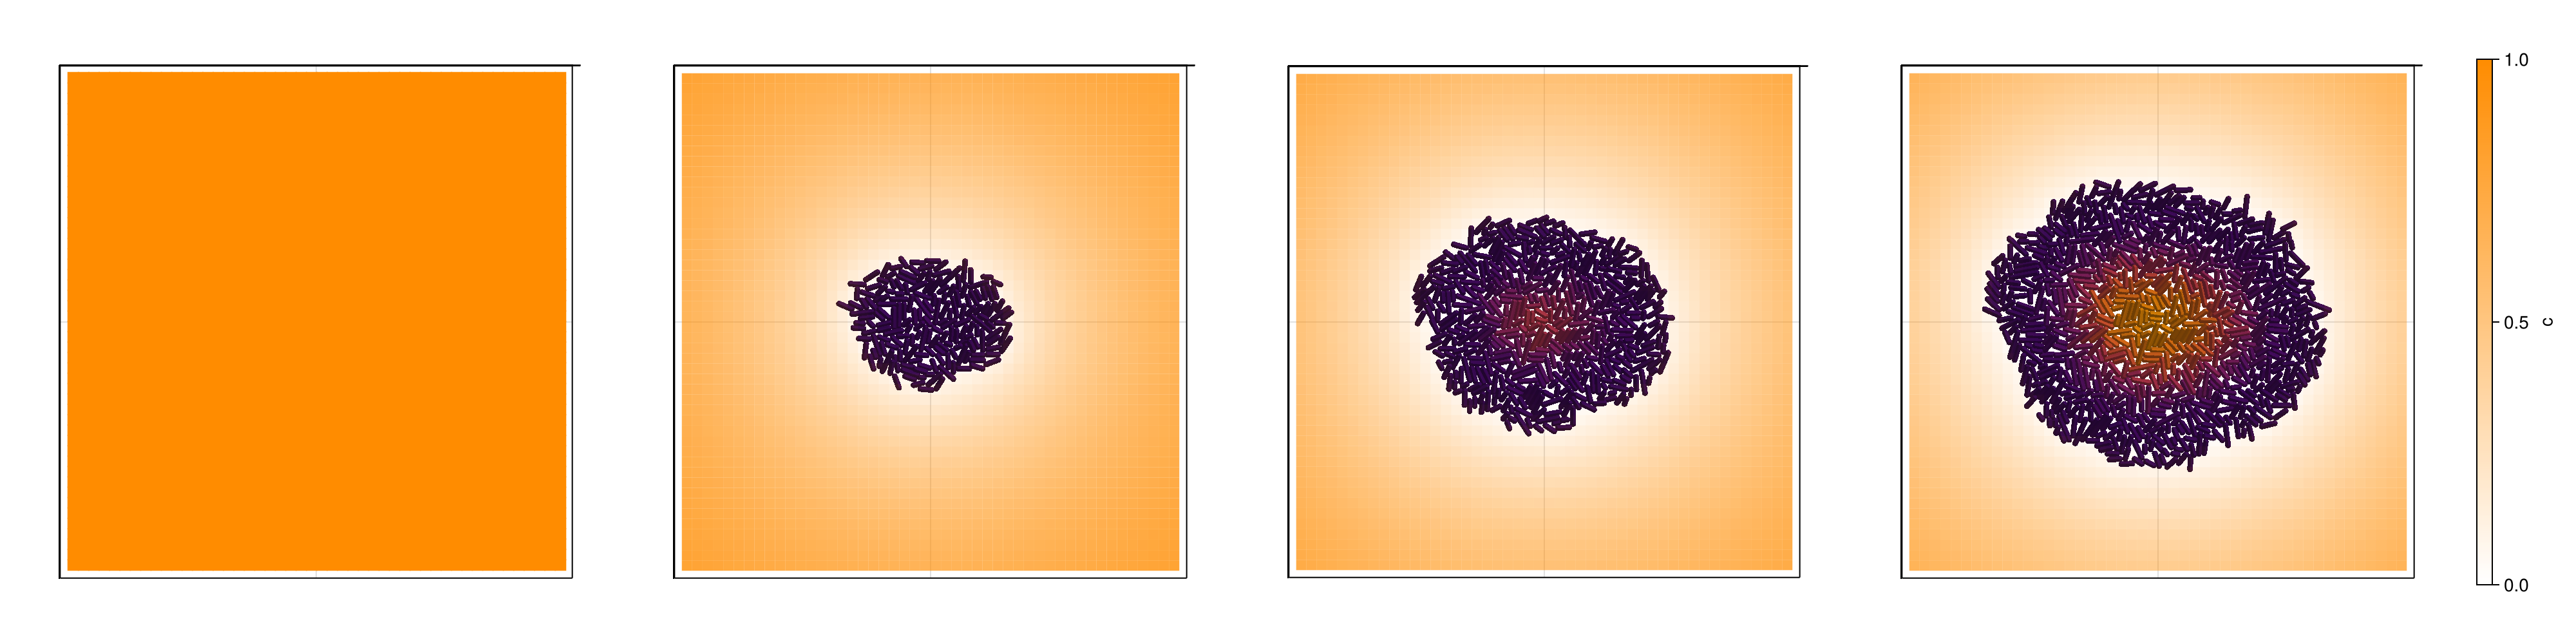

CairoMakie.Screen{IMAGE}


In [45]:
com_load,times=load_parameters_log("Tods_c.txt")
fig = Figure(size=(2000,500))

cmap_transp_orange = cgrad(
    [RGBAf(1.0, 0.55, 0, 0.0),   # verde con alfa 0 (transparente)
     RGBAf(1.0, 0.55, 0, 1.0)],  # verde con alfa 1 (opaco)
    506
)

colormap_c=cmap_transp_orange

# js = [1:round(Int, length(com_load)/4):length(com_load); length(com_load)]
# js =  length(com_load)
js = round.(Int, range(1, length(com_load), length=4))
for (i,j) in enumerate(js)
    ax = Axis3(fig[1,i],
                azimuth=3*π/2,
                elevation=π/2,
                zlabelvisible=false,
                zticklabelsvisible=false,
                zgridvisible=false,
                zspinesvisible=false,
                xticksvisible=false,
                yticksvisible=false,
                xticklabelsvisible=false,
                yticklabelsvisible=false,
                xlabelvisible=false,
                ylabelvisible=false

            )

    plotAgents2D!(
    ax,
    com_load[j][:x],
    com_load[j][:y],
    com_load[j][:d],
    com_load[j][:l],
    com_load[j][:theta],
    com_load[j][:Vm],
    colormap = Reverse(:inferno),
    colorrange =  (-280, -120),
    )

    m2 = heatmap!(ax,
        range(simBox_cpu[1,1],simBox_cpu[1,2],length=size(com.c)[1]),
        range(simBox_cpu[2,1],simBox_cpu[2,2],length=size(com.c)[1]),
        Float64.(hcat(com_load[j][:c]...)),
        colormap = colormap_c,
        colorrange = colorrange_c
    )

    xlims!(-50,50)
    ylims!(-50,50)
end
Colorbar(fig[1, length(js) + 1],
    colormap = colormap_c,
    colorrange = colorrange_c,
    label = "c"
)

display(fig)

In [46]:

# Crear figura y ejes
fig = Figure(size = (800, 600))
grid = fig[1, 1] = GridLayout()
ax = Axis(grid[1, 1]; aspect = DataAspect())
hidedecorations!(ax)     # oculta ticks, etiquetas y más
ax.xgridvisible = true
ax.ygridvisible = true

# colorrange = (0.0,  maximum(maximum(p -> maximum(p[:generation]), com_load)))
colorrange = (0.0,  2.)

Colorbar(fig[1, 2],
    colormap = Reverse(:inferno),
    colorrange =  (-280, -120),
    label = "V"
)


Makie.record(fig, "Colony.mp4", 1:5:Int(length(com_load)); framerate = 10) do j
 
    Makie.empty!(ax)
   
    plotAgents2D!(
        ax,
        com_load[j][:x],
        com_load[j][:y],
        com_load[j][:d],
        com_load[j][:l],
        com_load[j][:theta],
        com_load[j][:Vm],
        colormap = Reverse(:inferno),
        colorrange =  (-280, -120),
    )

    xlims!(ax, - (50), 50)
    ylims!(ax, - (50),  50)
end


"Colony.mp4"